In [61]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from lmfit import Parameters, minimize
from psyduck.operations import get_spin_operators
from psyduck.hamiltonians import quadrupole_hamiltonian_from_Vab, zeeman_hamiltonian, get_fq1, get_fq2
from psyduck.tensors import get_R_tensor, voigt_to_tensor
from psyduck.plotting import plot_quadrupole_tensor, spherical_plot_3d

In [62]:
Ix, Iy, Iz = get_spin_operators(7/2)

# Physical constants for Sb-123
Q_N = -0.69e-28    # Nuclear quadrupole moment (C·m²)
I_SPIN = 7/2
GAMMA_NUCLEAR = 5.55 * 1e6 # Nuclear Zeeman splitting (MHz/T)

In [63]:
nmr = np.array([[5172791, 5192239, 5211740, 5231304, 5250923, 5270595, 5290345], [5160688, 5168255, 5176257, 5184657, 5193455, 5202655, 5212240], [5193539, 5182071, 5171162, 5160824, 5151057, 5141862, 5133238],
                [5059454, 5031774, 5004403, 4977343, 4950602, 4924210, 4898143]])
thetas = np.array([0, 22.5, 45, 67.5])/180*np.pi
fq_1_measured = np.mean(np.diff(nmr, axis=1), axis=1)
fq_2_measured = np.mean(np.diff(np.diff(nmr, axis=1), axis=1), axis=1)
fq_3_measured = np.mean(np.diff(np.diff(np.diff(nmr, axis=1), axis=1), axis=1), axis=1)
f_ner1_measured = np.array([
    [1/695269,  1/794668, 1/1435812, 0, 1/1426646,  1/804481,  1/694418],
    [ 1/686240, 1/781800, 1/1392608, 0, 1/1432536,  1/794038,  1/684887],
    [ 1/724982, 1/820604, 1/1461844, 0, 1/1471447,  1/819658,  1/702738],
    [1/1007362, 1/1139615, 1/2027774, 0,  1/2062878, 1/1141658,  1/983045]
]) * 1e9
f_ner2_measured = 1/np.array([
    [6199939,  4560535, 3957246, 3999002, 4549282,  6302998],
    [5964587, 4554291, 3907868, 3985586, 4576766, 6594215],
     [3042804, 2118640, 1842177, 1828053, 2099015, 3039585],
    [2028237, 1397648, 1206481, 1203026, 1370836, 1985169]
]) * 1e9

In [64]:
nmr.shape

(4, 7)

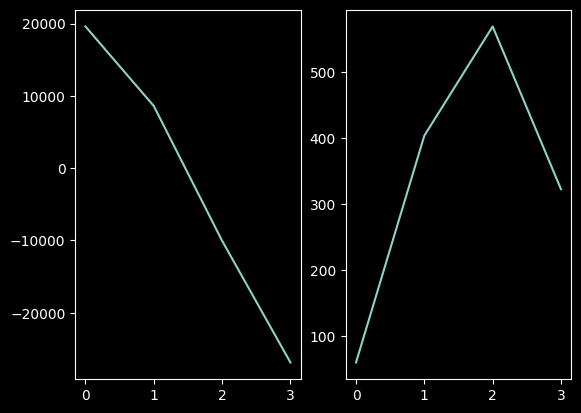

In [65]:
fig, ax = plt.subplots(1,2)
ax[0].plot(fq_1_measured)
ax[1].plot(fq_2_measured)

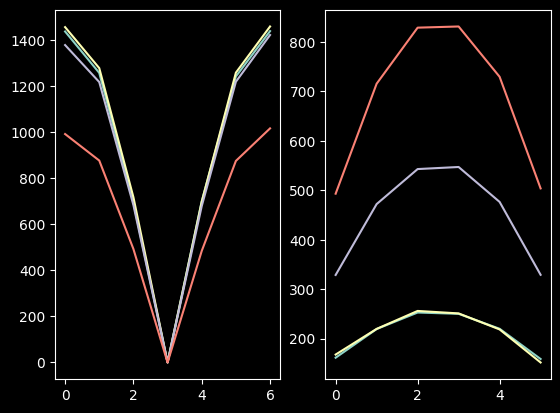

In [66]:
fig, ax = plt.subplots(1,2)
ax[0].plot(f_ner1_measured.T)
ax[1].plot(f_ner2_measured.T)

In [67]:
B0 = np.mean(nmr[0])/GAMMA_NUCLEAR

def make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    return np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]]) * 1e19

def ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, **kwargs):
    V_ab = make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
    H_q = quadrupole_hamiltonian_from_Vab(I_SPIN, V_ab, Q_N)
    H_zeeman = zeeman_hamiltonian(7/2, B0=B0, gamma=GAMMA_NUCLEAR, theta=theta)
    return H_zeeman + H_q

# R-tensor (Si, (110) orientation): maps AC field [Ex, Ey, Ez] → EFG Voigt vector
_R_tensor = get_R_tensor()   # (6, 3)

def _drive_in_eigenbasis(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z):
    """Drive Hamiltonian (from AC field E_ac) in the energy eigenbasis of H_ion."""
    E_ac       = np.array([E_x, E_y, E_z])
    EFG_tensor = voigt_to_tensor(_R_tensor @ E_ac)
    H_drive    = quadrupole_hamiltonian_from_Vab(I_SPIN, EFG_tensor, Q_N).full()
    H_ion      = ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
    _, evecs   = H_ion.eigenstates()
    U          = np.column_stack([v.full().flatten() for v in evecs])
    return U.conj().T @ H_drive @ U

def ner1(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, **kwargs):
    return np.abs(np.diag(_drive_in_eigenbasis(
        theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z), 1))

def ner2(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, scale=1.0):
    return np.abs(np.diag(_drive_in_eigenbasis(
        theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, scale*E_x, scale*E_y, scale*E_z), 2))

def nmr_frequencies(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, **kwargs):
    evals = ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz).eigenstates()[0]
    return np.flip(np.diff(evals)).flatten()


In [68]:
B0

np.float64(0.942598120978121)

In [69]:

def residual(params):
    p = params.valuesdict()
    fq1_arr = np.zeros(len(thetas))
    fq2_arr = np.zeros(len(thetas))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))
    return np.vstack([
        (fq1_arr - fq_1_measured) / np.max(fq_1_measured),
        (fq2_arr - fq_2_measured) / np.max(fq_2_measured),
    ])

params = Parameters()
params.add('Vxx', value=-4, min=-5,  max=5)
params.add('Vyy', value=1,  min=-5,  max=5)
params.add('Vzz', expr='- Vxx - Vyy')
params.add('Vxy', value=0,  min=-20, max=20)
params.add('Vyz', value=0,  min=-5,  max=20)
params.add('Vxz', value=0,  min=-5,  max=20)
# params.add('scale', value=0, min=0, max=0.1)

result = minimize(residual, params, method='leastsq')
result.params.pretty_print()

Name     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Vxx     2.595       -5        5  0.05225     True     None     None
Vxy     1.319      -20       20  0.05469     True     None     None
Vxz    0.3788       -5       20  0.04196     True     None     None
Vyy    -0.966       -5        5  0.06512     True     None     None
Vyz     1.355       -5       20  0.04369     True     None     None
Vzz    -1.629     -inf      inf  0.02473    False - Vxx - Vyy     None


In [70]:
result

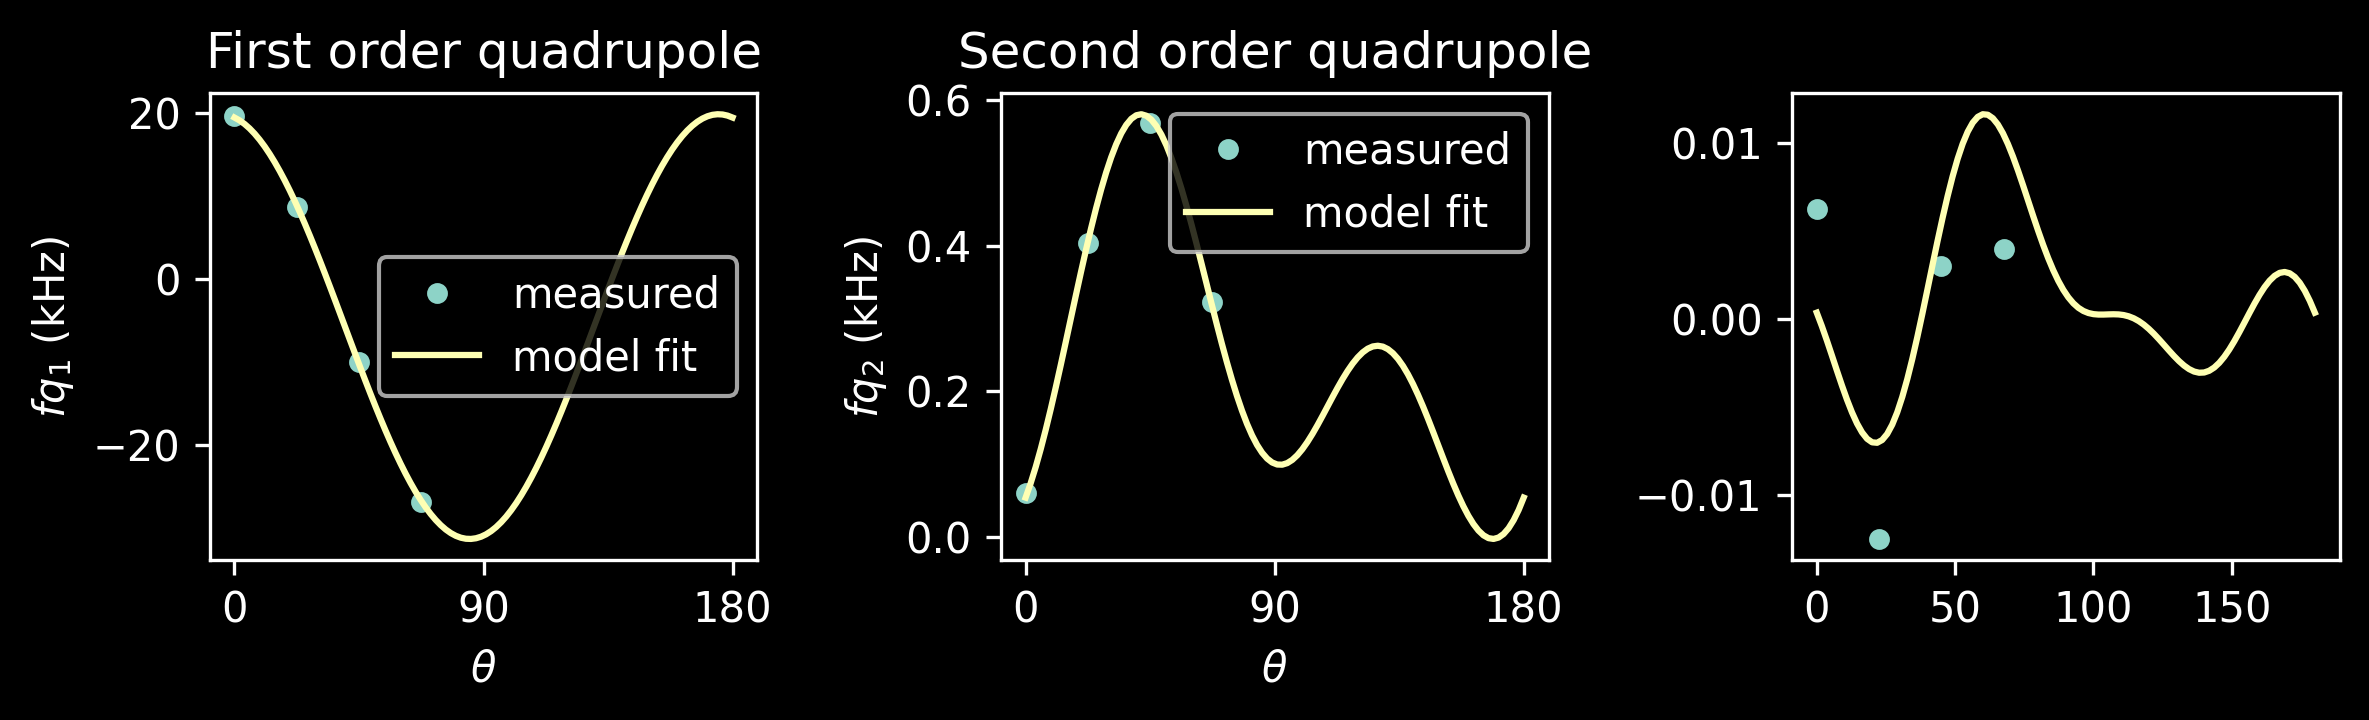

In [71]:
p = result.params.valuesdict()
thetas_fit = np.linspace(0, np.pi, 100)
fq1_arr = np.zeros(len(thetas_fit))
fq2_arr = np.zeros(len(thetas_fit))
fq3_arr = np.zeros(len(thetas_fit))
for t, theta in enumerate(thetas_fit):
    evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
    fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
    fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))
    fq3_arr[t] = np.mean(np.diff(np.diff(np.diff(np.diff(evals)))))

fig, ax = plt.subplots(1, 3, figsize=(8, 2.5), dpi=300)
ax[0].plot(thetas / np.pi * 180, fq_1_measured * 1e-3, '.', markersize=8, label='measured')
ax[0].plot(thetas_fit / np.pi * 180, fq1_arr * 1e-3, label='model fit')
ax[1].plot(thetas / np.pi * 180, fq_2_measured * 1e-3, '.', markersize=8, label='measured')
ax[1].plot(thetas_fit / np.pi * 180, fq2_arr * 1e-3, label='model fit')
ax[2].plot(thetas / np.pi * 180, fq_3_measured * 1e-3, '.', markersize=8, label='measured')
ax[2].plot(thetas_fit / np.pi * 180, fq3_arr * 1e-3, label='model fit')
for a, title, ylabel in zip(ax,
        ['First order quadrupole', 'Second order quadrupole'],
        ['$fq_1$ (kHz)', '$fq_2$ (kHz)']):
    a.legend()
    a.set_title(title)
    a.set_ylabel(ylabel)
    a.set_xlabel(r'$\theta$')
    a.set_xticks([0, 90, 180])
plt.tight_layout()

In [72]:
p = result.params.valuesdict()
ner1_arr = np.zeros((len(thetas), 7))
ner2_arr = np.zeros((len(thetas), 6))
for t, theta in enumerate(thetas):
    ner1_arr[t] = ner1(theta, **p, E_x=100000, E_y=100000, E_z=100000)
    ner2_arr[t] = ner2(theta, **p, E_x=40000, E_y=40000, E_z=100000)

In [73]:
ner1_arr

array([[529.2821578 , 464.65325177, 261.81545835,   3.26595972,
        260.61206398, 469.78483709, 541.10393174],
       [479.57450809, 415.92246088, 230.0951891 ,  12.07616683,
        235.27595756, 416.14940398, 474.1258714 ],
       [539.95576804, 465.68968815, 254.34849356,  12.83559258,
        268.32460309, 468.81247406, 530.40821986],
       [475.36848524, 411.77290434, 225.9586377 ,   7.80244938,
        239.38299117, 420.49488279, 477.8409106 ]])

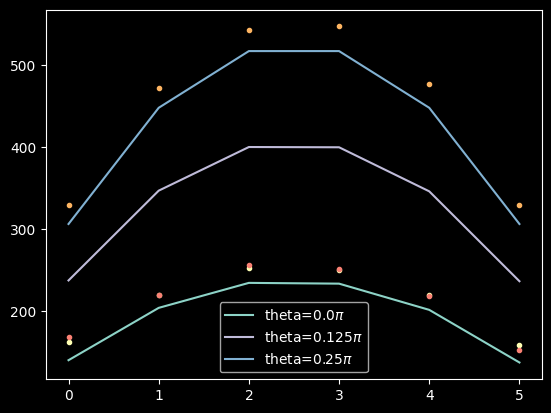

In [74]:
for t, theta in enumerate(thetas[:-1]):
    plt.plot(ner2_arr[t], label=r'theta={}$\pi$'.format(theta/np.pi))
    plt.plot(f_ner2_measured[t], '.')
plt.legend()

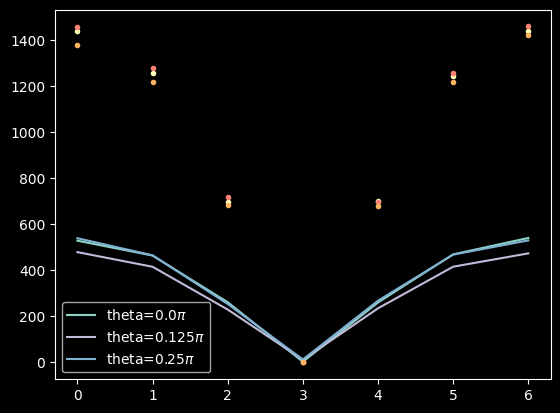

In [75]:
for t, theta in enumerate(thetas[:-1]):
    plt.plot(ner1_arr[t], label=r'theta={}$\pi$'.format(theta/np.pi))
    plt.plot(f_ner1_measured[t], '.')
plt.legend()

In [76]:
p_tensor = result.params.valuesdict()
_ner1_mask = f_ner1_measured != 0   # skip the symmetry-forbidden m=-1/2→+1/2 transition

def residual_full(params):
    p = params.valuesdict()
    fq1_arr   = np.zeros(len(thetas))
    fq2_arr   = np.zeros(len(thetas))
    ner1_arr  = np.zeros((len(thetas), 7))
    ner2_arr  = np.zeros((len(thetas), 6))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p_tensor, **p).eigenstates()[0]
        fq1_arr[t]   = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
        ner1_arr[t]  = ner1(theta, **p_tensor, **p)
        ner2_arr[t]  = ner2(theta, **p_tensor, **p)
    return np.hstack([
        (ner1_arr - f_ner1_measured)[_ner1_mask]      / np.max(np.abs(f_ner1_measured[_ner1_mask])),
        (ner2_arr - f_ner2_measured).flatten()        / np.max(np.abs(f_ner2_measured)),
    ])

# scale_y ~ 270000 from NER1 outer transition (~1438 Hz measured)
# scale_z ~ 52000  from NER2 outer transition (~161  Hz measured)
# scale_x fixed at 0: both scale_x and scale_y drive NER1 ({Iy,Iz} vs {Ix,Iz})
#   and are poorly separated; leave scale_x free only if fit quality demands it
params = Parameters()
params.add('E_x', value=20,   min=-1e7, max=1e7)
params.add('E_y', value=1,  min=-1e7, max=1e7)
params.add('E_z', value=1,   min=-1e7, max=1e7)
params.add('scale', value=1, min=0.00001, max=10)


result_full = minimize(residual_full, params, method='leastsq')
result_full


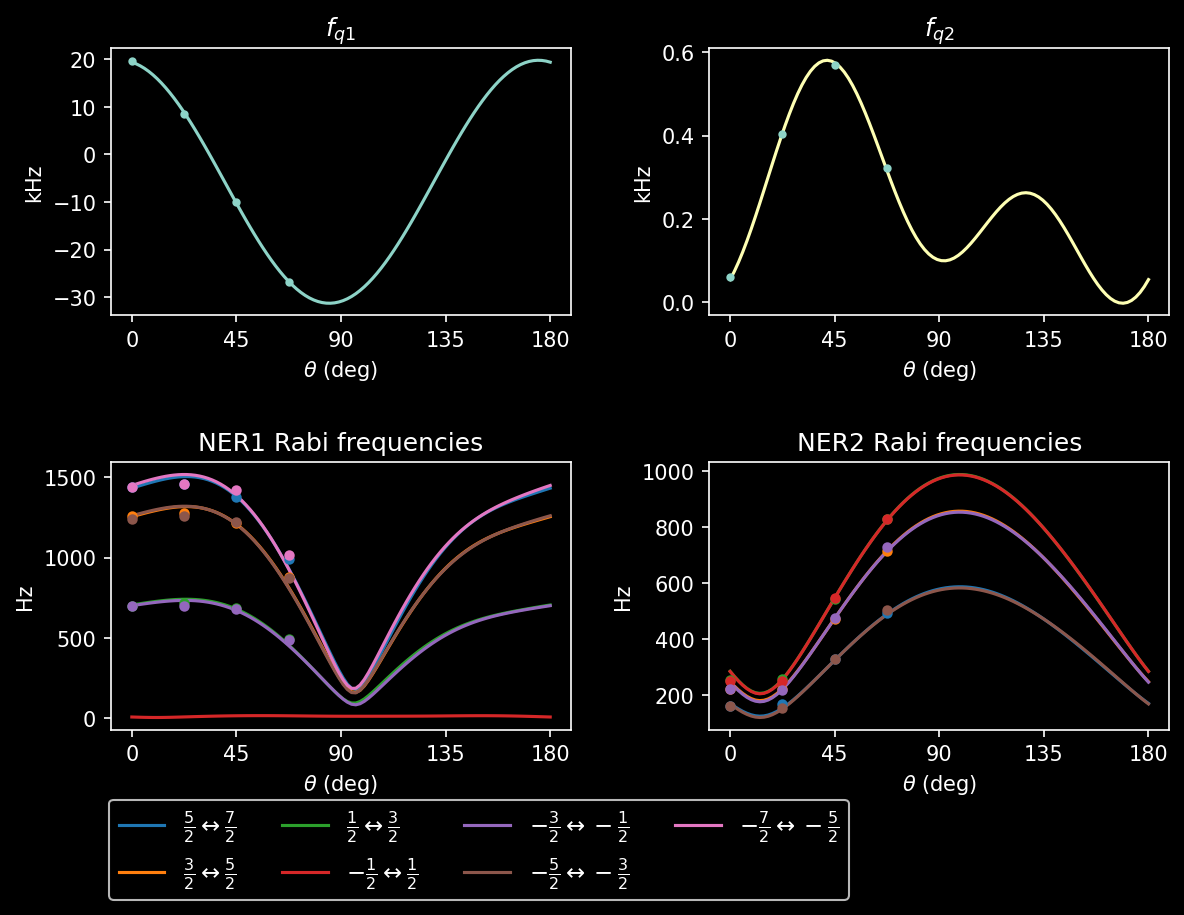

In [77]:

# Eigenstates in ascending energy order: ψ_0 = |m=+7/2⟩, ..., ψ_7 = |m=-7/2⟩
# NER1: H[i, i+1]  →  adjacent-m pairs
# NER2: H[i, i+2]  →  next-nearest-m pairs
_ner1_labels = [
    r'$\frac{5}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{3}{2}\leftrightarrow\frac{5}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{3}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{3}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{5}{2}$',
]
_ner2_labels = [
    r'$\frac{3}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{5}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{3}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{3}{2}$',
]

p_full = result_full.params.valuesdict()
thetas_fit = np.linspace(0, np.pi, 100)

fq1_fit  = np.zeros(len(thetas_fit))
fq2_fit  = np.zeros(len(thetas_fit))
ner1_fit = np.zeros((len(thetas_fit), 7))
ner2_fit = np.zeros((len(thetas_fit), 6))
for t, th in enumerate(thetas_fit):
    evals = ionized_hamiltonian(th, **p_tensor, **p_full).eigenstates()[0]
    fq1_fit[t]   = np.mean(np.diff(np.diff(evals)))
    fq2_fit[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
    ner1_fit[t]  = ner1(th, **p_tensor, **p_full)
    ner2_fit[t]  = ner2(th, **p_tensor, **p_full)

theta_deg     = thetas / np.pi * 180
theta_fit_deg = thetas_fit / np.pi * 180
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(2, 2, figsize=(8, 6), dpi=150)
axes = ax.flatten()

axes[0].plot(theta_deg, fq_1_measured * 1e-3, '.', zorder=5)
axes[0].plot(theta_fit_deg, fq1_fit * 1e-3, color='C0')
axes[0].set_title('$f_{q1}$')
axes[0].set_ylabel('kHz')

axes[1].plot(theta_deg, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].plot(theta_fit_deg, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$')
axes[1].set_ylabel('kHz')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(theta_deg[mask_i], f_ner1_measured[mask_i, i], '.', markersize=8,
                 color=c, zorder=5)
    axes[2].plot(theta_fit_deg, ner1_fit[:, i], color=c, label=_ner1_labels[i])
axes[2].set_title('NER1 Rabi frequencies')
axes[2].set_ylabel('Hz')
axes[2].legend(fontsize=11, ncol=4, loc='upper center',
               bbox_to_anchor=(0.8, -0.22), framealpha=0.9)

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(theta_deg, f_ner2_measured[:, i], '.', markersize=8, color=c, zorder=5)
    axes[3].plot(theta_fit_deg, ner2_fit[:, i], color=c, label=_ner2_labels[i])
axes[3].set_title('NER2 Rabi frequencies')
axes[3].set_ylabel('Hz')
# axes[3].legend(fontsize=8, ncol=3, loc='upper center',
               # bbox_to_anchor=(0.5, -0.22), framealpha=0.9)

for a in axes:
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_xticks([0, 45, 90, 135, 180])

fig.tight_layout()
fig.subplots_adjust(wspace=0.3, hspace=0.55, bottom=0.18)


# visualize the tensor

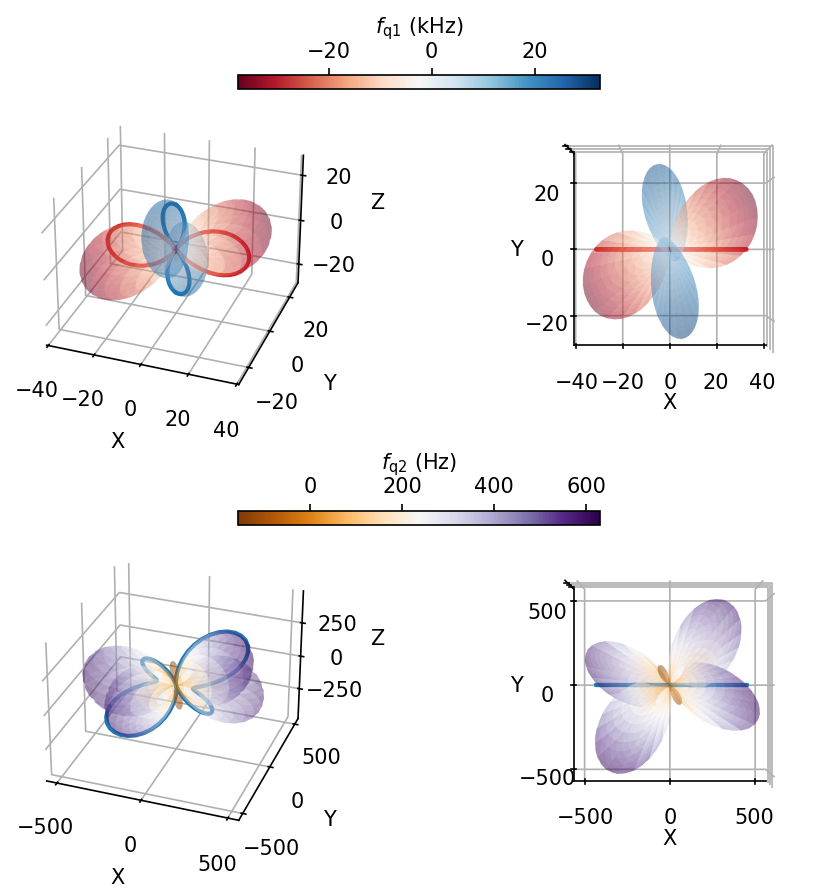

In [78]:
Vxx = p_tensor['Vxx']
Vyy = p_tensor['Vyy']
Vzz = p_tensor['Vzz']
Vxy = p_tensor['Vxy']
Vyz = p_tensor['Vyz']
Vxz = p_tensor['Vxz']
V_ab = np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]]) * 1e19

plot_quadrupole_tensor(V_ab, I_SPIN, B0, GAMMA_NUCLEAR, Q_N)

In [79]:
theta_grid = np.linspace(0, np.pi, 100)
phi_grid = np.linspace(0, 2 * np.pi, 100)
fq1_grid = get_fq1(V_ab, I_SPIN, B0, GAMMA_NUCLEAR, Q_N, theta_grid, phi_grid)

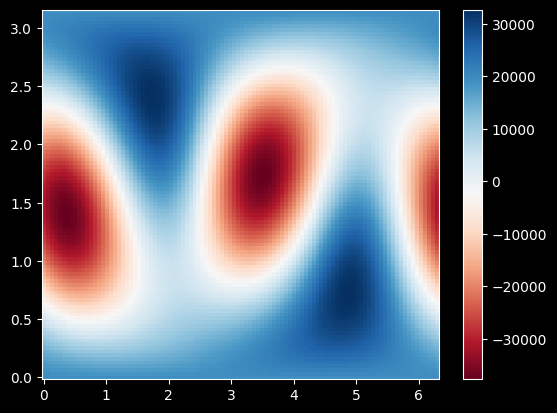

In [80]:
plt.pcolormesh(phi_grid, theta_grid, fq1_grid, cmap='RdBu')
plt.colorbar()

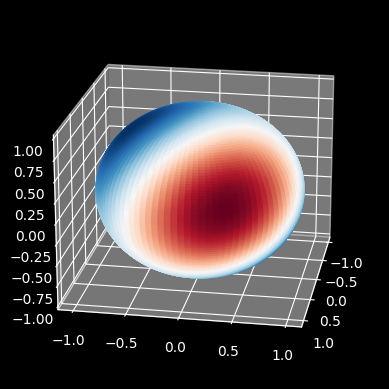

In [81]:
fig, ax = spherical_plot_3d(fq1_grid, cmap='RdBu')
ax.view_init(20, 10)

# Play around with visualization

C:\GitHub\Psyduck\psyduck\plotting\quadrupole_plot.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  fq1[i, j] = np.mean(np.diff(np.diff(evals)))
C:\GitHub\Psyduck\psyduck\plotting\quadrupole_plot.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  fq2[i, j] = np.mean(np.diff(np.diff(np.diff(evals))))


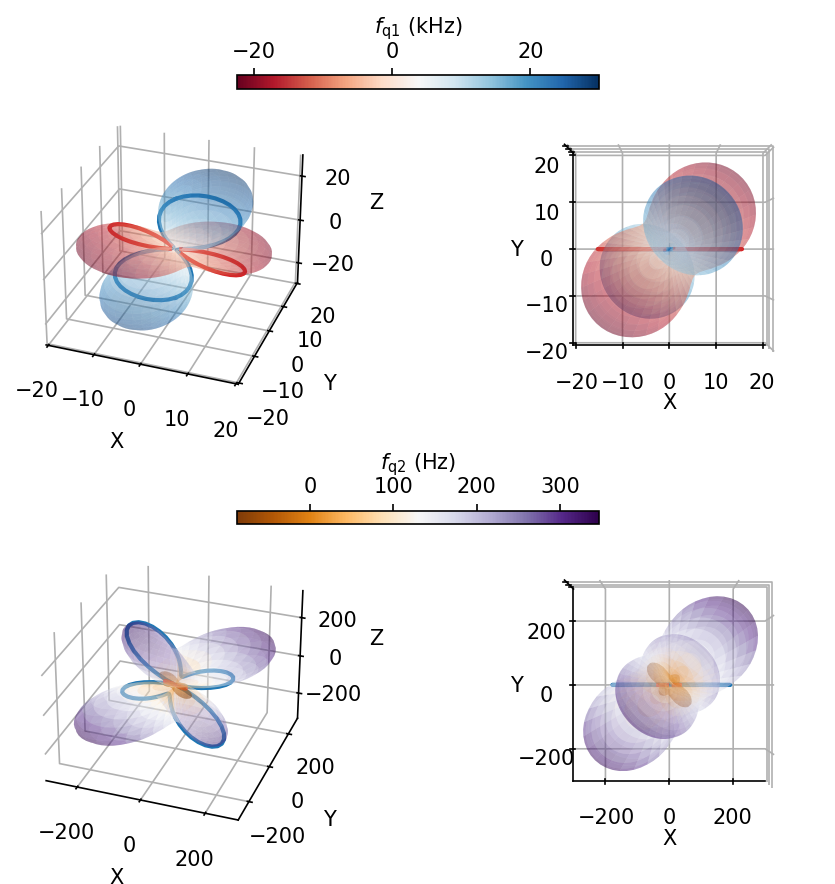

In [60]:
from psyduck.tensors import get_Q_tensor, Qab_to_Vab

# define rotation angles
_theta = np.pi/8
_phi = np.pi/4
_psi = np.pi/2

Q_tensor = get_Q_tensor(30e3, eta=0.5, theta=_theta, phi=_phi, psi=_psi)
V_tensor = Qab_to_Vab(Q_tensor, I_SPIN, Q_N)
plot_quadrupole_tensor(V_tensor, I_SPIN, B0, GAMMA_NUCLEAR, Q_N)

## find quadrupole stark shift sweetspot

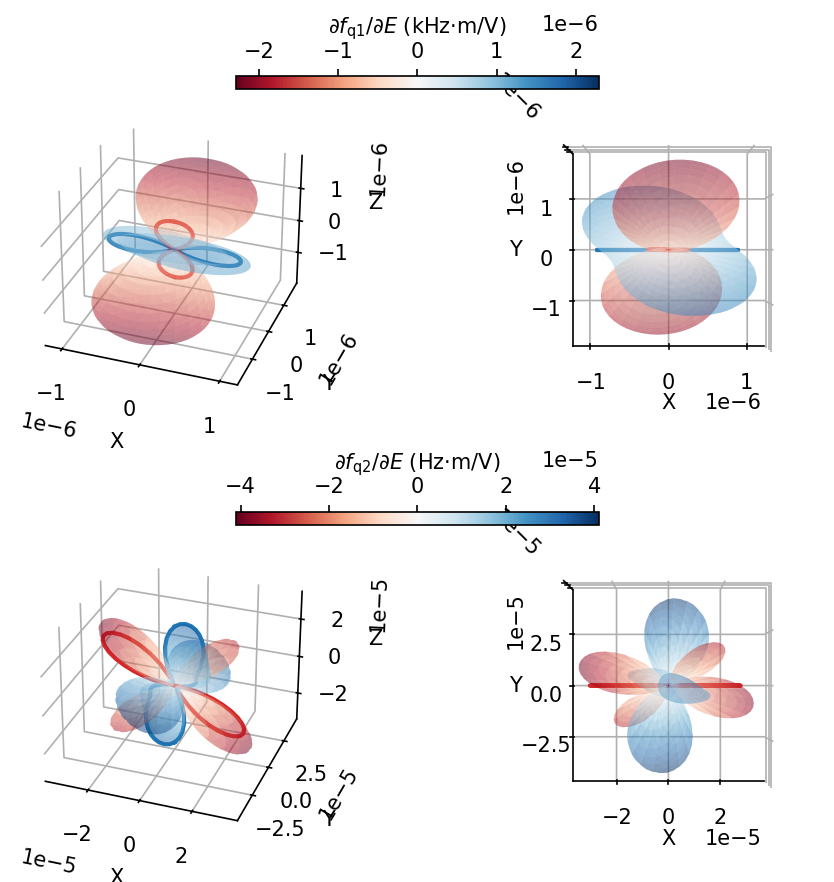

In [82]:
from psyduck.hamiltonians import get_quadrupole_stark_shift
from psyduck.plotting import plot_quadrupole_stark_shift

E_vec = np.array([p_full['E_x'], p_full['E_y'], p_full['E_z']])
thetas_ss = np.linspace(0, np.pi, 50)
phis_ss = np.linspace(0, 2 * np.pi, 100)

dfq1_stark, dfq2_stark = get_quadrupole_stark_shift(
    V_ab, E_vec, I_SPIN, B0, GAMMA_NUCLEAR, Q_N, thetas_ss, phis_ss
)

plot_quadrupole_stark_shift(dfq1_stark, dfq2_stark, thetas_ss, phis_ss)

In [83]:
q_stark_shift_measured = np.array([100/0.75, 88.529, -5.351, -102.260])

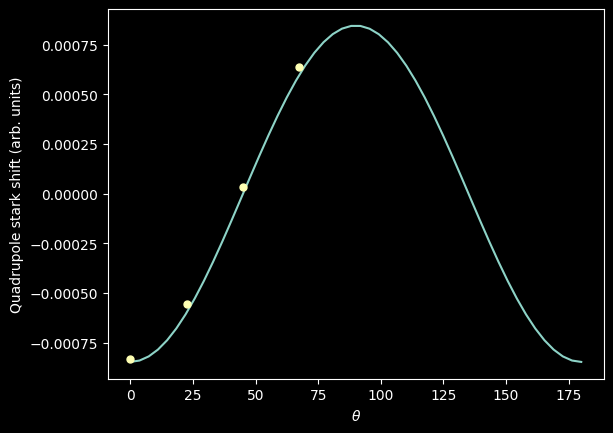

In [103]:
fig, ax = plt.subplots(1,1)
ax.plot(thetas_ss/np.pi*180, dfq1_stark[:, 0])
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'Quadrupole stark shift (arb. units)')
scale_dc_gate = 6.25e-6

ax.plot(thetas/np.pi*180, q_stark_shift_measured*-scale_dc_gate, '.', markersize=10)

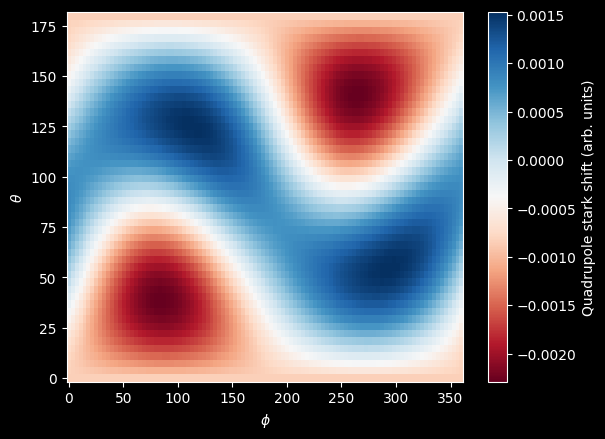

In [62]:
plt.pcolormesh(phis_ss/np.pi*180, thetas_ss/np.pi*180, dfq1_stark, cmap='RdBu')
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\theta$')
plt.colorbar(label=r'Quadrupole stark shift (arb. units)')